In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [35]:
df = pd.read_csv("StudentPerformanceFactors.csv")

In [36]:
df.shape

(6607, 20)

In [37]:
df.head(3)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74


In [38]:
df.drop(columns=['Family_Income','School_Type', 'Internet_Access', 'Teacher_Quality', 'Physical_Activity','Learning_Disabilities','Parental_Education_Level','Distance_from_Home', 'Gender'], inplace=True)

In [39]:
df.isnull().sum()

Hours_Studied                 0
Attendance                    0
Parental_Involvement          0
Access_to_Resources           0
Extracurricular_Activities    0
Sleep_Hours                   0
Previous_Scores               0
Motivation_Level              0
Tutoring_Sessions             0
Peer_Influence                0
Exam_Score                    0
dtype: int64

In [40]:
df.head(3)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Peer_Influence,Exam_Score
0,23,84,Low,High,No,7,73,Low,0,Positive,67
1,19,64,Low,Medium,No,8,59,Low,2,Negative,61
2,24,98,Medium,Medium,Yes,7,91,Medium,2,Neutral,74


In [41]:
df['Access_to_Resources'] = df['Access_to_Resources'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

In [42]:
df['Parental_Involvement'] = df['Parental_Involvement'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

In [43]:
df['Extracurricular_Activities'] = df['Extracurricular_Activities'].map({
    'No': 0,
    'Yes': 1
})

In [44]:
df['Motivation_Level'] = df['Motivation_Level'].map({
    'Low': 0,
    'Medium': 1,
    'High': 2
})

In [45]:
df['Peer_Influence'] = df['Peer_Influence'].map({
    'Negative': 0,
    'Neutral': 1,
    'Positive': 2
})

In [46]:
df.head(3)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Peer_Influence,Exam_Score
0,23,84,0,2,0,7,73,0,0,2,67
1,19,64,0,1,0,8,59,0,2,0,61
2,24,98,1,1,1,7,91,1,2,1,74


In [47]:
df.describe()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Tutoring_Sessions,Peer_Influence,Exam_Score
count,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,1.086423,1.100197,0.596035,7.02906,75.070531,0.906463,1.493719,1.190858,67.235659
std,5.990594,11.547475,0.695521,0.698347,0.490728,1.46812,14.399784,0.695798,1.230570,0.755876,3.890456
min,1.000000,60.000000,0.000000,0.000000,0.000000,4.00000,50.000000,0.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,1.000000,1.000000,0.000000,6.00000,63.000000,0.000000,1.000000,1.000000,65.000000
50%,20.000000,80.000000,1.000000,1.000000,1.000000,7.00000,75.000000,1.000000,1.000000,1.000000,67.000000
75%,24.000000,90.000000,2.000000,2.000000,1.000000,8.00000,88.000000,1.000000,2.000000,2.000000,69.000000
max,44.000000,100.000000,2.000000,2.000000,1.000000,10.00000,100.000000,2.000000,8.000000,2.000000,101.000000


In [48]:
df = df[
    (df['Hours_Studied'] + df['Sleep_Hours']) <= 24
]

In [49]:
df.shape

(2246, 11)

In [50]:
df[['Hours_Studied', 'Sleep_Hours']].describe()

,Hours_Studied,Sleep_Hours
count,2246.000000,2246.000000
mean,13.702582,6.634907
std,3.401514,1.439906
min,1.000000,4.000000
25%,12.000000,6.000000
50%,14.000000,7.000000
75%,16.000000,8.000000
max,20.000000,10.000000


In [51]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [54]:
X = df[[
    'Hours_Studied',
    'Attendance',
    'Previous_Scores',
    'Sleep_Hours',
    'Tutoring_Sessions',
    'Access_to_Resources',
    'Parental_Involvement',
    'Motivation_Level',
    'Peer_Influence'
]]

y = df['Exam_Score']

In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [56]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
y_pred = model.predict(X_test)

In [58]:
from sklearn.metrics import r2_score

score = r2_score(y_test, y_pred)

print("R2 Score:", score)

R2 Score: 0.8616420438108429


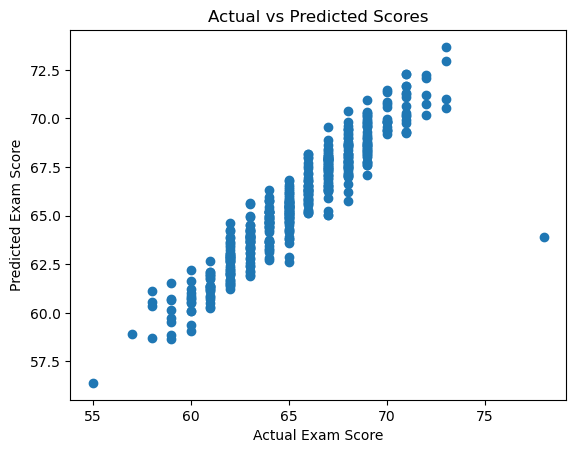

In [59]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")

plt.title("Actual vs Predicted Scores")

plt.show()

In [64]:
import pandas as pd

def predict_score(
    hours,
    attendance,
    previous,
    sleep,
    tutoring,
    resources,
    parental,
    motivation,
    peer
):
    
    data = pd.DataFrame([[
        hours,
        attendance,
        previous,
        sleep,
        tutoring,
        resources,
        parental,
        motivation,
        peer
    ]], columns=[
        'Hours_Studied',
        'Attendance',
        'Previous_Scores',
        'Sleep_Hours',
        'Tutoring_Sessions',
        'Access_to_Resources',
        'Parental_Involvement',
        'Motivation_Level',
        'Peer_Influence'
    ])
    
    prediction = model.predict(data)[0]
    
    return prediction

In [65]:
def recommend(
    hours,
    attendance,
    previous,
    sleep,
    tutoring,
    resources,
    parental,
    motivation,
    peer
):
    
    score = predict_score(
        hours,
        attendance,
        previous,
        sleep,
        tutoring,
        resources,
        parental,
        motivation,
        peer
    )
    
    print(f"Predicted Exam Score: {score:.2f}")
    
    if score < 60:
        print("Recommendation: Improve attendance and increase study consistency.")
    
    elif score < 75:
        print("Recommendation: Focus more on practice and revision.")
    
    else:
        print("Recommendation: Good academic performance. Maintain your routine.")

In [66]:
recommend(
    10,   # Hours_Studied
    85,   # Attendance
    80,   # Previous_Scores
    7,    # Sleep_Hours
    3,    # Tutoring_Sessions
    2,    # Access_to_Resources
    2,    # Parental_Involvement
    2,    # Motivation_Level
    1     # Peer_Influence
)

Predicted Exam Score: 68.82
Recommendation: Focus more on practice and revision.


In [67]:
import joblib

joblib.dump(model, 'model.pkl')

['model.pkl']